# RANDOM FOREST + SMOTE 

## I. Librerías

In [1]:
import numpy as np
import pandas as pd
import glob
import warnings

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE
from collections import Counter

warnings.filterwarnings('ignore')


## Data Loading

In [ ]:
import os
DATASETS = glob.glob(os.path.join("dataset", "*.csv"))
print(DATASETS) 


dfs = [pd.read_csv(path) for path in DATASETS]
df = pd.concat(dfs, ignore_index=True)

['C:\\Users\\victo\\Desktop\\dataset\\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv', 'C:\\Users\\victo\\Desktop\\dataset\\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv', 'C:\\Users\\victo\\Desktop\\dataset\\Friday-WorkingHours-Morning.pcap_ISCX.csv', 'C:\\Users\\victo\\Desktop\\dataset\\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv', 'C:\\Users\\victo\\Desktop\\dataset\\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv', 'C:\\Users\\victo\\Desktop\\dataset\\Tuesday-WorkingHours.pcap_ISCX.csv']


In [3]:
# Drop rows with missing values and verify no nulls remain
df = df.dropna()
df.isnull().sum() * 100 / df.shape[0]


 Destination Port              0.0
 Flow Duration                 0.0
 Total Fwd Packets             0.0
 Total Backward Packets        0.0
Total Length of Fwd Packets    0.0
                              ... 
Idle Mean                      0.0
 Idle Std                      0.0
 Idle Max                      0.0
 Idle Min                      0.0
 Label                         0.0
Length: 79, dtype: float64

In [4]:
df.head()
df.shape
df.info()


<class 'pandas.DataFrame'>
Index: 1607836 entries, 0 to 1608121
Data columns (total 79 columns):
 #   Column                        Non-Null Count    Dtype  
---  ------                        --------------    -----  
 0    Destination Port             1607836 non-null  int64  
 1    Flow Duration                1607836 non-null  int64  
 2    Total Fwd Packets            1607836 non-null  int64  
 3    Total Backward Packets       1607836 non-null  int64  
 4   Total Length of Fwd Packets   1607836 non-null  int64  
 5    Total Length of Bwd Packets  1607836 non-null  int64  
 6    Fwd Packet Length Max        1607836 non-null  int64  
 7    Fwd Packet Length Min        1607836 non-null  int64  
 8    Fwd Packet Length Mean       1607836 non-null  float64
 9    Fwd Packet Length Std        1607836 non-null  float64
 10  Bwd Packet Length Max         1607836 non-null  int64  
 11   Bwd Packet Length Min        1607836 non-null  int64  
 12   Bwd Packet Length Mean       1607836 non-nu

## Clean Data

In [5]:
# Remove leading/trailing whitespace from column names
df.columns = df.columns.str.strip()

# Separate features and target
X = df.drop('Label', axis=1)
y = df['Label']

# Replace infinite values with NaN, then drop affected rows
X = X.replace([np.inf, -np.inf], np.nan)
mask = X.notna().all(axis=1)
X = X[mask]
y = y[mask]


## Training / Test Split

In [6]:

from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size   = 0.8,
    random_state = 1234,
    shuffle      = True,
    stratify     = y
)


## SMOTE

In [7]:
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report
from collections import Counter

# ==============================
# BEFORE SMOTE
# ==============================
print('Before Over Sampling:')
print(Counter(y_train))
print()

# ==============================
# CREATE SAMPLING STRATEGY
# ==============================
cap = 10000  # maximum samples per minority class after oversampling

counts = Counter(y_train)

# Only oversample classes that fall below the cap
sampling_dict = {cls: cap for cls, c in counts.items() if c < cap}

print('Sampling strategy:', sampling_dict)
print()

# ==============================
# APPLY SMOTE
# ==============================
sm1 = SMOTE(
    sampling_strategy=sampling_dict,
    random_state=2,
    k_neighbors=3  # conservative choice: some minority classes have very few samples
)

X_train_res, y_train_res = sm1.fit_resample(X_train, y_train.to_numpy())

# ==============================
# AFTER SMOTE
# ==============================
print('After Over Sampling:')
print(Counter(y_train_res))
print()

print('After Over Sampling, the shape of train_X:', X_train_res.shape)
print('After Over Sampling, the shape of train_y:', y_train_res.shape)


Before Over Sampling:
Counter({'BENIGN': 1041725, 'PortScan': 127043, 'DDoS': 102420, 'FTP-Patator': 6348, 'SSH-Patator': 4717, 'Bot': 1565, 'Web Attack � Brute Force': 1205, 'Web Attack � XSS': 522, 'Infiltration': 29, 'Web Attack � Sql Injection': 17})

Sampling strategy: {'FTP-Patator': 10000, 'SSH-Patator': 10000, 'Web Attack � Brute Force': 10000, 'Bot': 10000, 'Web Attack � XSS': 10000, 'Web Attack � Sql Injection': 10000, 'Infiltration': 10000}

After Over Sampling:
Counter({'BENIGN': 1041725, 'PortScan': 127043, 'DDoS': 102420, 'FTP-Patator': 10000, 'SSH-Patator': 10000, 'Web Attack � Brute Force': 10000, 'Bot': 10000, 'Web Attack � XSS': 10000, 'Web Attack � Sql Injection': 10000, 'Infiltration': 10000})

After Over Sampling, the shape of train_X: (1341188, 78)
After Over Sampling, the shape of train_y: (1341188,)


## Subsampling for Hyperparameter Search

In [8]:
X_sample, _, y_sample, _ = train_test_split(
    X_train_res,
    y_train_res,
    train_size=10000,
    stratify=y_train_res,
    random_state=42
)

print('Subsample shape:', X_sample.shape)
print(pd.Series(y_sample).value_counts())


Subsample shape: (10000, 78)
BENIGN                        7767
PortScan                       947
DDoS                           764
FTP-Patator                     75
Bot                             75
Infiltration                    75
Web Attack � Sql Injection      75
SSH-Patator                     74
Web Attack � Brute Force        74
Web Attack � XSS                74
Name: count, dtype: int64


## Hyperparameter Search

In [ ]:
# Round 1: search over n_estimators, max_features, max_depth, criterion
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_features': [5, 7, 9],
    'max_depth': [None, 10, 20],
    'criterion': ['gini', 'entropy']
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=123)

grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=123, n_jobs=1),
    param_grid=param_grid,
    scoring='f1_macro',
    n_jobs=1,
    cv=cv,
    refit=True,
    verbose=1,
    return_train_score=True
)

grid.fit(X_sample, y_sample)

results_cv = pd.DataFrame(grid.cv_results_)
(
    results_cv
    .filter(regex='(param_|mean_test_score|std_test_score|rank_test_score)')
    .sort_values('mean_test_score', ascending=False)
    .head(8)
)


Fitting 3 folds for each of 54 candidates, totalling 162 fits


,param_criterion,param_max_depth,param_max_features,param_n_estimators,mean_test_score,std_test_score,rank_test_score
35,entropy,None,9,150,0.891300,0.016372,1
52,entropy,20,9,100,0.890701,0.012220,2
53,entropy,20,9,150,0.889865,0.018397,3
51,entropy,20,9,50,0.886440,0.014850,4
34,entropy,None,9,100,0.885711,0.015913,5
48,entropy,20,7,50,0.883979,0.015120,6
33,entropy,None,9,50,0.883876,0.014938,7
49,entropy,20,7,100,0.883115,0.012014,8


Selected: `criterion=entropy`. Moving on to choose `n_estimators`, `max_features`, and `max_depth`.

In [11]:
# Round 2: refine n_estimators, max_features, max_depth (criterion fixed to gini)

param_grid = {
    'criterion': ['entropy'],           
    'max_features': [7, 8, 9, 10],         
    'max_depth': [10, 15, 20, None],    
    'n_estimators': [80, 100, 150, 200] 
}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=123)

grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=123, n_jobs=1),
    param_grid=param_grid,
    scoring='f1_macro',
    n_jobs=1,
    cv=cv,
    refit=True,
    verbose=1,
    return_train_score=True
)

grid.fit(X_sample, y_sample)

results_cv = pd.DataFrame(grid.cv_results_)
(
    results_cv
    .filter(regex='(param_|mean_test_score|std_test_score|rank_test_score)')
    .sort_values('mean_test_score', ascending=False)
    .head(8)
)


Fitting 3 folds for each of 64 candidates, totalling 192 fits


,param_criterion,param_max_depth,param_max_features,param_n_estimators,mean_test_score,std_test_score,rank_test_score
58,entropy,None,9,150,0.891300,0.016372,1
36,entropy,20,8,80,0.891156,0.005965,2
52,entropy,None,8,80,0.891130,0.005836,3
41,entropy,20,9,100,0.890701,0.012220,4
45,entropy,20,10,100,0.890161,0.006647,5
42,entropy,20,9,150,0.889865,0.018397,6
53,entropy,None,8,100,0.889656,0.007796,7
59,entropy,None,9,200,0.889200,0.015683,8


In [12]:
# Round 3: narrow search 

param_grid = {
    'criterion': ['entropy'],
    'max_features': [7, 8, 9],
    'max_depth': [18, 20, 22, None],
    'n_estimators': [80, 100, 120, 150]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=123)

grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=123, n_jobs=1),
    param_grid=param_grid,
    scoring='f1_macro',
    n_jobs=1,
    cv=cv,
    refit=True,
    verbose=1,
    return_train_score=True
)

grid.fit(X_sample, y_sample)

results_cv = pd.DataFrame(grid.cv_results_)
(
    results_cv
    .filter(regex='(param_|mean_test_score|std_test_score|rank_test_score)')
    .sort_values('mean_test_score', ascending=False)
    .head(8)
)


Fitting 3 folds for each of 48 candidates, totalling 144 fits


,param_criterion,param_max_depth,param_max_features,param_n_estimators,mean_test_score,std_test_score,rank_test_score
47,entropy,None,9,150,0.891300,0.016372,1
16,entropy,20,8,80,0.891156,0.005965,2
28,entropy,22,8,80,0.891130,0.005836,3
40,entropy,None,8,80,0.891130,0.005836,3
9,entropy,18,9,100,0.891104,0.011250,5
10,entropy,18,9,120,0.890984,0.014027,6
11,entropy,18,9,150,0.890773,0.016011,7
21,entropy,20,9,100,0.890701,0.012220,8


In [ ]:
# Round 4: final round
param_grid = {
    'criterion': ['entropy'],
    'max_features': [8, 9],        
    'max_depth': [20, None],       
    'n_estimators': [80, 150],  
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=123)

grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=123, n_jobs=1),
    param_grid=param_grid,
    scoring='f1_macro',
    n_jobs=1,
    cv=cv,
    refit=True,
    verbose=1,
    return_train_score=True
)

grid.fit(X_sample, y_sample)

results_cv = pd.DataFrame(grid.cv_results_)
(
    results_cv
    .filter(regex='(param_|mean_test_score|std_test_score|rank_test_score)')
    .sort_values('mean_test_score', ascending=False)
    .head(8)
)


Fitting 3 folds for each of 72 candidates, totalling 216 fits


,param_criterion,param_max_depth,param_max_features,param_min_samples_leaf,param_min_samples_split,param_n_estimators,mean_test_score,std_test_score,rank_test_score
55,entropy,None,9,1,2,150,0.891300,0.016372,1
0,entropy,20,8,1,2,80,0.891156,0.005965,2
36,entropy,None,8,1,2,80,0.891130,0.005836,3
19,entropy,20,9,1,2,150,0.889865,0.018397,4
22,entropy,20,9,1,10,80,0.887516,0.008662,5
18,entropy,20,9,1,2,80,0.887486,0.012366,6
37,entropy,None,8,1,2,150,0.886759,0.009436,7
56,entropy,None,9,1,5,80,0.886366,0.010879,8


## Final Model

In [15]:
model_final = RandomForestClassifier(
            n_estimators = 80,
            criterion    = 'entropy',
            max_depth    = 20,
            max_features = 8,
            oob_score    = True,
            n_jobs       = -1,
            random_state = 123
         )
model_final.fit(X_train_res, y_train_res)
print(f'OOB score: {model_final.oob_score_:.4f}')


OOB score: 0.9961


## Evaluation

### 1. Train

In [16]:
predictions_train = model_final.predict(X_train)

accuracy_train = accuracy_score(
            y_true    = y_train,
            y_pred    = predictions_train,
            normalize = True
           )
print('\n Accuracy in train: {:.2f} %'.format(100 * accuracy_train))

print(classification_report(y_train, predictions_train))



 Accuracy in train: 99.90 %
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00   1041725
                       Bot       0.85      0.98      0.91      1565
                      DDoS       1.00      1.00      1.00    102420
               FTP-Patator       1.00      1.00      1.00      6348
              Infiltration       1.00      1.00      1.00        29
                  PortScan       0.99      1.00      1.00    127043
               SSH-Patator       1.00      1.00      1.00      4717
  Web Attack � Brute Force       0.98      0.75      0.85      1205
Web Attack � Sql Injection       0.85      1.00      0.92        17
          Web Attack � XSS       0.62      0.96      0.76       522

                  accuracy                           1.00   1285591
                 macro avg       0.93      0.97      0.94   1285591
              weighted avg       1.00      1.00      1.00   1285591



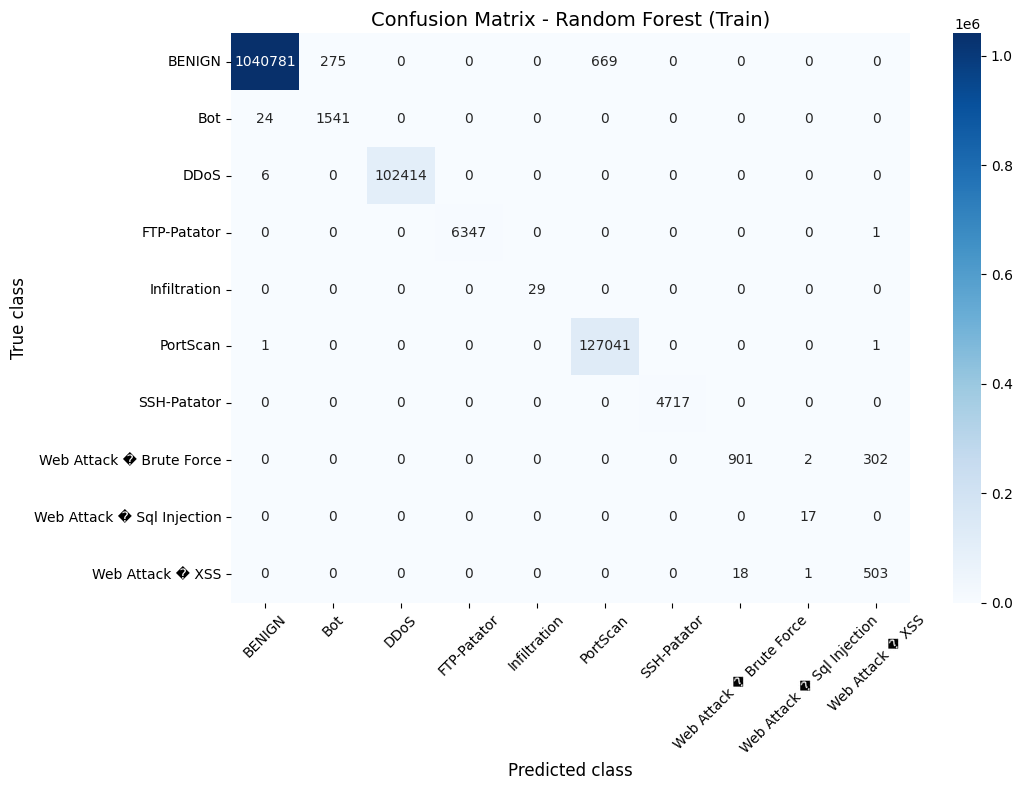

In [17]:
labels = sorted(y_train.unique())
cm = confusion_matrix(y_train, predictions_train, labels=labels)

plt.figure(figsize=(11,8))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel('Predicted class', fontsize=12)
plt.ylabel('True class', fontsize=12)
plt.title('Confusion Matrix - Random Forest (Train)', fontsize=14)

plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### 2. Test

In [18]:
pred_test = model_final.predict(X_test)

print('Accuracy test: {:.2f} %'.format(100 * accuracy_score(y_test, pred_test)))
print(classification_report(y_test, pred_test))


Accuracy test: 99.82 %
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    260431
                       Bot       0.72      0.91      0.80       391
                      DDoS       1.00      1.00      1.00     25605
               FTP-Patator       1.00      1.00      1.00      1587
              Infiltration       1.00      0.71      0.83         7
                  PortScan       0.99      1.00      1.00     31761
               SSH-Patator       1.00      1.00      1.00      1180
  Web Attack � Brute Force       0.84      0.57      0.68       302
Web Attack � Sql Injection       0.30      0.75      0.43         4
          Web Attack � XSS       0.43      0.72      0.54       130

                  accuracy                           1.00    321398
                 macro avg       0.83      0.87      0.83    321398
              weighted avg       1.00      1.00      1.00    321398



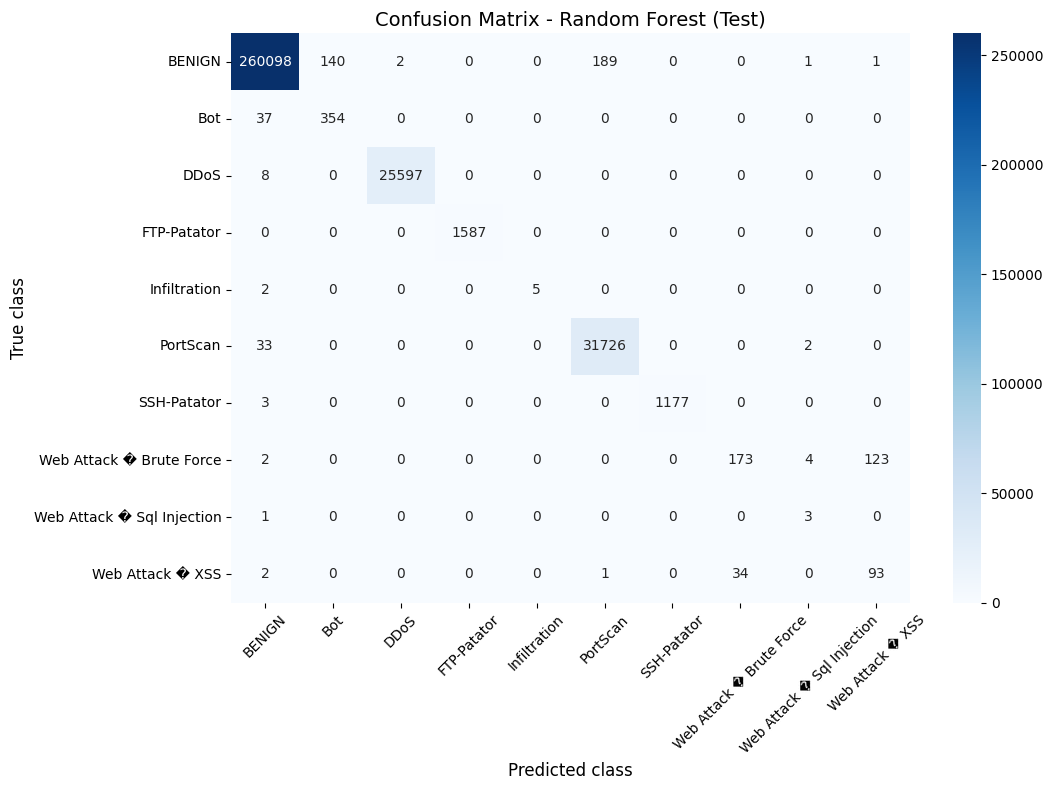

In [19]:
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, pred_test, labels=labels)

plt.figure(figsize=(11,8))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel('Predicted class', fontsize=12)
plt.ylabel('True class', fontsize=12)
plt.title('Confusion Matrix - Random Forest (Test)', fontsize=14)

plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


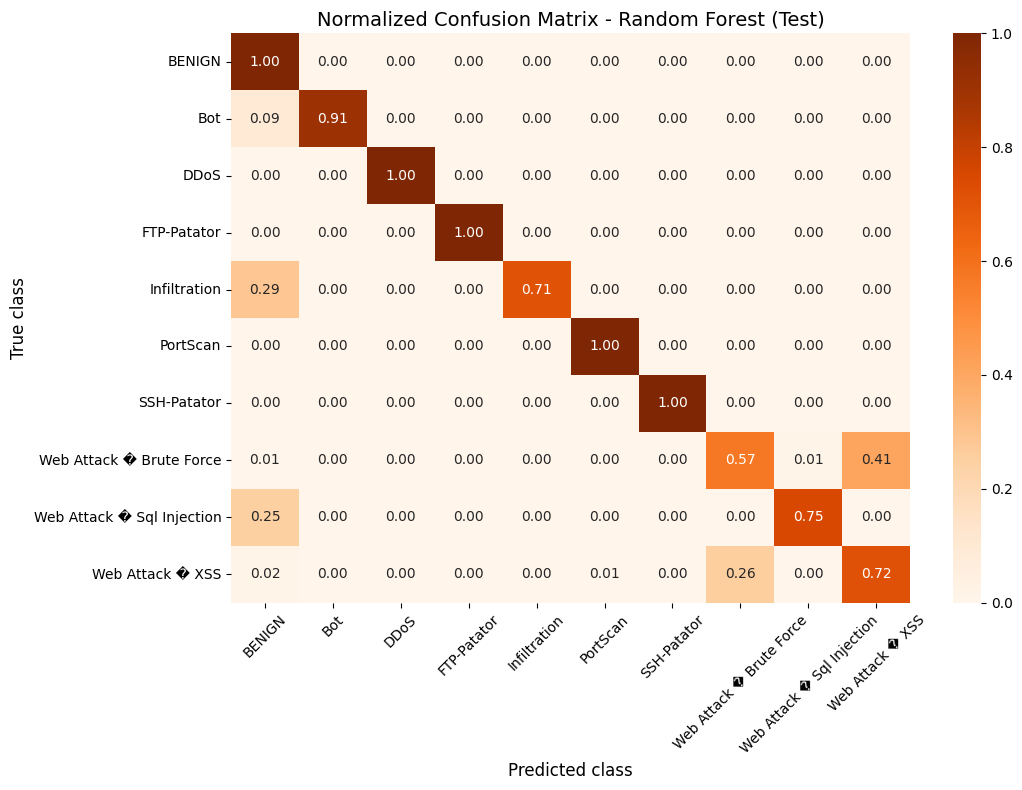

In [20]:
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(11,8))
sns.heatmap(cm_norm,
            annot=True,
            fmt='.2f',
            cmap='Oranges',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel('Predicted class', fontsize=12)
plt.ylabel('True class', fontsize=12)
plt.title('Normalized Confusion Matrix - Random Forest (Test)', fontsize=14)

plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## Feature Importance

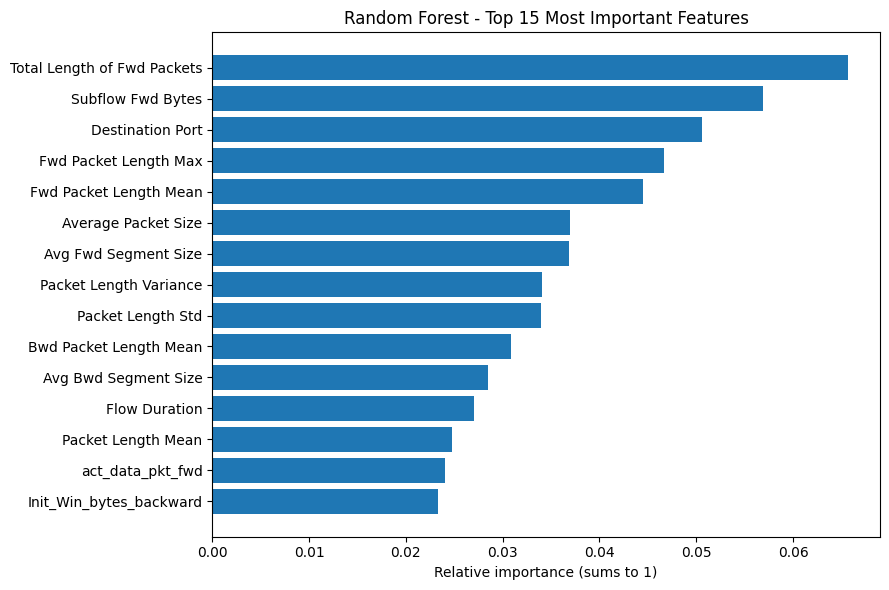

                    Feature  Importance
Total Length of Fwd Packets    0.065698
          Subflow Fwd Bytes    0.056904
           Destination Port    0.050584
      Fwd Packet Length Max    0.046696
     Fwd Packet Length Mean    0.044453
        Average Packet Size    0.037003
       Avg Fwd Segment Size    0.036861
     Packet Length Variance    0.034043
          Packet Length Std    0.033935
     Bwd Packet Length Mean    0.030852
       Avg Bwd Segment Size    0.028527
              Flow Duration    0.027085
         Packet Length Mean    0.024776
           act_data_pkt_fwd    0.024074
    Init_Win_bytes_backward    0.023371
                Fwd IAT Min    0.022072
     Init_Win_bytes_forward    0.021609
        Fwd Header Length.1    0.020868
      Bwd Packet Length Std    0.018902
               Flow Bytes/s    0.017441


In [ ]:
importances = model_final.feature_importances_

feature_names = (
    X_train_res.columns.tolist()
    if isinstance(X_train_res, pd.DataFrame)
    else [f'f{i}' for i in range(len(importances))]
)

imp_df = (
    pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })
    .sort_values('Importance', ascending=False)
)

top_n = 15
imp_top = imp_df.head(top_n).iloc[::-1]

plt.figure(figsize=(9, 6))
plt.barh(imp_top['Feature'], imp_top['Importance'])
plt.xlabel('Relative importance (sums to 1)')
plt.title(f'Random Forest - Top {top_n} Most Important Features')
plt.tight_layout()
plt.show()**

print(imp_df.head(20).to_string(index=False))
